<h1 align="center"> Car Damage Classification using Deep Learning <h1/>

## 📌 Objective

This project builds a deep learning image classification system to classify different types of car damage using CNNs and transfer learning models such as EfficientNet and ResNet.

## 🚀 Key Highlights

- Build baseline CNN models
- Reduce overfitting using regularization
- Apply transfer learning
- Compare model performance
- Deploy the final model using Streamlit and FastAPI

### Import Libraries

In [1]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import torchvision.models as models
from matplotlib import pyplot as plt
from torch.utils.data import random_split

In [2]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Data Load and Transformation

In [3]:
image_transforms=transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2,contrast=0.2),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])

The dataset size is small. Deep learning models generally perform better with very large datasets because they learn millions of parameters. When the dataset is limited, the model may overfit and fail to generalize well to new images.

To overcome this, we use **data augmentation**. Data augmentation artificially increases dataset diversity by applying random transformations such as horizontal flipping, rotation, cropping, zooming, and brightness changes. These transformations create different variations of the same image during training without modifying the original image files.

This helps the model learn more robust features and improves generalization performance.

Those normalization values are the channel-wise mean and standard deviation of the ImageNet dataset.

ImageNet images are RGB images, so:

- 0.485 → mean of Red channel
- 0.456 → mean of Green channel
- 0.406 → mean of Blue channel

and similarly for standard deviations.

Your transform pipeline is related to ImageNet because pretrained models like:

- ResNet
- VGG
- EfficientNet

were trained on the ImageNet dataset using images normalized with these exact statistics.

So when you use a pretrained model:

`model = models.resnet18(weights="IMAGENET1K_V1")`

the model expects inputs to be preprocessed in the same way as during ImageNet training.

**Why normalization matters**

After `ToTensor()`:

pixel values become [0,1]

Normalization then transforms them roughly into a distribution centered around 0:

$$
x_{normalized} = \frac{x - mean}{std}
$$

This helps because neural networks train and perform better when inputs have a stable distribution.

**Why specifically these numbers?**

Because during ImageNet training, researchers computed:

- average RGB values across millions of images
- standard deviation across millions of images

and used them consistently during training.

If you don't use the same normalization with pretrained models:

- predictions may become worse
- transfer learning performance can drop

because the input distribution changes from what the model learned.

**Why resize to `(224,224)`?**

Most ImageNet pretrained CNNs were trained on:

224 x 224

images.

So:

transforms.Resize((224,224))

makes your input compatible with the model architecture and training setup.

In [4]:
dataset_path = "./dataset"

dataset=datasets.ImageFolder(root=dataset_path,transform=image_transforms)
len(dataset)

2300

In [5]:
class_names=dataset.classes
class_names

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [6]:
num_classes=len(dataset.classes)
num_classes

6

In [7]:
train_size=int(0.75*len(dataset))
val_size=len(dataset)-train_size

train_size,val_size

(1725, 575)

In [8]:
train_dataset,val_dataset = random_split(dataset,[train_size,val_size])

In [9]:
train_loader = DataLoader(train_dataset, batch_size=32,  shuffle=True)
val_loader  = DataLoader(val_dataset,   batch_size=32,  shuffle=False)

In [10]:
for images,labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [11]:
labels[0]

tensor(2)

In [12]:
images[0].shape

torch.Size([3, 224, 224])

In [13]:
images[0]

tensor([[[-1.9980, -1.9980, -1.9980,  ..., -1.3302, -1.7583, -1.9980],
         [-1.9980, -1.9980, -1.9980,  ..., -1.4329, -1.8097, -1.9980],
         [-1.5185, -1.3815, -0.6109,  ..., -1.2788, -1.7583, -1.9980],
         ...,
         [-1.9980, -1.4158, -0.0116,  ..., -1.2445, -1.6555, -1.7754],
         [-1.9980, -1.5014, -0.3883,  ..., -1.9980, -1.9980, -1.9980],
         [-1.9980, -1.4672, -0.3712,  ..., -1.9980, -1.9980, -1.9980]],

        [[-1.9132, -1.9132, -1.9132,  ..., -0.9853, -1.5805, -1.9132],
         [-1.9132, -1.9132, -1.9132,  ..., -1.0378, -1.6155, -1.9132],
         [-1.4405, -1.3004, -0.5476,  ..., -0.8627, -1.5630, -1.9132],
         ...,
         [-1.9132, -1.3004,  0.1527,  ..., -1.1954, -1.5980, -1.7031],
         [-1.9132, -1.3880, -0.2325,  ..., -1.9132, -1.9132, -1.9132],
         [-1.9132, -1.3529, -0.2150,  ..., -1.9132, -1.9132, -1.9132]],

        [[-1.6824, -1.6824, -1.6824,  ..., -0.7413, -1.3513, -1.6824],
         [-1.6824, -1.6824, -1.6824,  ..., -0

In [14]:
images[0].permute(1,2,0).shape

torch.Size([224, 224, 3])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


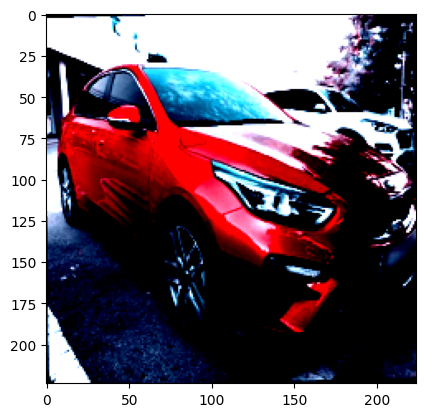

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(10,6))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].permute(1,2,0))
    ax.set_title(class_names[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

## Model1 : CNN

In [16]:
class CarClassifierCNN(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.network= nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=16,kernel_size=3,stride=1,padding=1), #output (16,224,224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0),# (16,112,112)
            nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3,stride=1,padding=1), #output (32,112,112)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0),
            nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,stride=1,padding=1), #output (64,56,56)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0), # output (64,28,28)
            nn.Flatten(),
            nn.Linear(64*28*28,512),
            nn.ReLU(),
            nn.Linear(512,num_classes)
        )

    def forward(self,x):
        x=self.network(x)
        return x

In [17]:
#Instantiate the model, loss function and optimizer

model=CarClassifierCNN(num_classes=num_classes).to(device)
optimizer=optim.Adam(model.parameters(),lr=0.001)
criterion=nn.CrossEntropyLoss()

In [18]:
images.size(0)

32

In [19]:
len(train_loader.dataset)

1725

In [20]:
def train_model(model,criterion,optimizer,epochs=5):
    start=time.time()
    
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    for epoch in range(epochs):
        model.train()
        running_loss=0.0
        for batch_num, (images,labels) in enumerate(train_loader):

            images,labels = images.to(device),labels.to(device)

            #zeroing gradients
            optimizer.zero_grad()

            #forward pass
            outputs=model(images)
            loss=criterion(outputs,labels)

            #backward pass
            loss.backward()
            optimizer.step()

            running_loss+=loss.item()*images.size(0)

        epoch_loss=running_loss/len(train_loader.dataset)     # Average loss per image for the entire epoch
        train_losses.append(epoch_loss)
        
        
        # Validation
        model.eval()
        val_loss = 0.0
        correct=0
        total=0
        all_labels=[]
        all_predictions=[]

        with torch.no_grad():
            for images,labels in val_loader:
                images,labels = images.to(device),labels.to(device)
                output=model(images)
                
                loss=criterion(output,labels)
                val_loss+=loss.item()*images.size(0)
                
                _,predictions=torch.max(output.data,1)
                correct+=(predictions==labels).sum().item()
                total+=labels.size(0)
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predictions.cpu().numpy())
            
            epoch_val_loss = val_loss / len(val_loader.dataset)
            accuracy=(100*correct)/total
            val_losses.append(epoch_val_loss)
            val_accuracies.append(accuracy)
            
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {epoch_loss:.2f} | "
            f"Val Loss: {epoch_val_loss:.2f} | "
            f"Val Accuracy: {accuracy:.2f}%"
            )
        
    end=time.time()
    print(f"Execution Time {end-start} seconds")
    return all_labels,all_predictions, train_losses,val_losses, val_accuracies

labels contains the true class indices (ground truth) for each image in the batch.

So during:

``` text
outputs = model(images)
loss = criterion(outputs, labels)
```

the model predictions (outputs) are compared against the correct answers (labels).

Suppose you have 4 car classes:

```text
0 → Audi
1 → BMW
2 → Tesla
3 → Toyota
```

and a batch contains:

```text
Image 1 → BMW
Image 2 → Tesla
Image 3 → Audi
```

then:

`labels = tensor([1, 2, 0])`

These labels are automatically assigned by:

`datasets.ImageFolder()`

based on folder names.

**What are outputs?**

The model produces raw scores (logits).

Example:

outputs =
tensor([

 [0.2, 2.1, 0.5, 0.1],

 [0.3, 0.4, 3.2, 0.2],

 [2.5, 0.1, 0.3, 0.2]
])

Shape:

[batch_size, num_classes]

Each row contains scores for all classes.

**How loss is computed**

If using:

criterion = nn.CrossEntropyLoss()

then PyTorch internally:

1. Applies Softmax to outputs
2. Compares predicted probabilities against true labels
3. Calculates classification error

So:

loss = criterion(outputs, labels)

means:

Compare model predictions
with the correct class index
for each image

Example:

outputs[0] = [0.2, 2.1, 0.5, 0.1]

labels[0]  = 1

Model predicts highest score at index 1 → correct prediction (BMW).

In [ ]:
def plot_metrics(train_losses, val_losses, val_accuracies):

    # Loss Plot
    plt.figure(figsize=(8,5))

    plt.plot(train_losses, label="Training Loss")
    plt.plot(val_losses, label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.title("Training vs Validation Loss")

    plt.legend()

    plt.show()

    # Accuracy Plot
    plt.figure(figsize=(8,5))

    plt.plot(val_accuracies)

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.title("Validation Accuracy")

    plt.show()

In [21]:
all_labels,all_predictions, train_losses,val_losses, val_accuracies=train_model(model,criterion,optimizer,epochs=5)

Batch Number: 10, Epoch :1, Loss: 1.81
Batch Number: 20, Epoch :1, Loss: 1.76
Batch Number: 30, Epoch :1, Loss: 1.69
Batch Number: 40, Epoch :1, Loss: 1.66
Batch Number: 50, Epoch :1, Loss: 1.41
Epoch: [1/5], Avg Loss = 1.7777 
Validation Accuracy: 41.57%***
Batch Number: 10, Epoch :2, Loss: 1.28
Batch Number: 20, Epoch :2, Loss: 1.45
Batch Number: 30, Epoch :2, Loss: 1.36
Batch Number: 40, Epoch :2, Loss: 1.54
Batch Number: 50, Epoch :2, Loss: 1.36
Epoch: [2/5], Avg Loss = 1.3811 
Validation Accuracy: 47.13%***
Batch Number: 10, Epoch :3, Loss: 1.33
Batch Number: 20, Epoch :3, Loss: 1.01
Batch Number: 30, Epoch :3, Loss: 1.18
Batch Number: 40, Epoch :3, Loss: 1.09
Batch Number: 50, Epoch :3, Loss: 1.02
Epoch: [3/5], Avg Loss = 1.1932 
Validation Accuracy: 50.78%***
Batch Number: 10, Epoch :4, Loss: 1.14
Batch Number: 20, Epoch :4, Loss: 1.46
Batch Number: 30, Epoch :4, Loss: 0.97
Batch Number: 40, Epoch :4, Loss: 1.26
Batch Number: 50, Epoch :4, Loss: 1.06
Epoch: [4/5], Avg Loss = 1.1

We can see from above the training loss is improving but accuracy isnt changing much. This means the model is overfitting. To resolve this we do regularisation techniques like dropout layers, batch normalisation etc.

## Model 2 : CNN with Regularisation

In [22]:
class CarClassifierCNNwithRegularistion(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.network= nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=16,kernel_size=3,stride=1,padding=1), #output (16,224,224)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0),# (16,112,112)
            nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3,stride=1,padding=1), #output (32,112,112)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0),
            nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,stride=1,padding=1), #output (64,56,56)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0), # output (64,28,28)
            nn.Flatten(),
            nn.Linear(64*28*28,512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512,num_classes)
        )

    def forward(self,x):
        x=self.network(x)
        return x

In [23]:
#Instantiate the model, loss function and optimizer

model=CarClassifierCNNwithRegularistion(num_classes=num_classes).to(device)
optimizer=optim.Adam(model.parameters(),lr=0.001,weight_decay=1e-4)
criterion=nn.CrossEntropyLoss()

In [24]:
all_labels,all_predictions, train_losses,val_losses, val_accuracies=train_model(model,criterion,optimizer,epochs=10)

Batch Number: 10, Epoch :1, Loss: 10.27
Batch Number: 20, Epoch :1, Loss: 6.58
Batch Number: 30, Epoch :1, Loss: 2.01
Batch Number: 40, Epoch :1, Loss: 1.44
Batch Number: 50, Epoch :1, Loss: 1.73
Epoch: [1/10], Avg Loss = 7.9665 
Validation Accuracy: 35.48%***
Batch Number: 10, Epoch :2, Loss: 1.52
Batch Number: 20, Epoch :2, Loss: 1.55
Batch Number: 30, Epoch :2, Loss: 1.20
Batch Number: 40, Epoch :2, Loss: 1.24
Batch Number: 50, Epoch :2, Loss: 1.81
Epoch: [2/10], Avg Loss = 1.5030 
Validation Accuracy: 41.57%***
Batch Number: 10, Epoch :3, Loss: 1.28
Batch Number: 20, Epoch :3, Loss: 1.67
Batch Number: 30, Epoch :3, Loss: 1.31
Batch Number: 40, Epoch :3, Loss: 1.76
Batch Number: 50, Epoch :3, Loss: 1.27
Epoch: [3/10], Avg Loss = 1.4368 
Validation Accuracy: 48.87%***
Batch Number: 10, Epoch :4, Loss: 1.17
Batch Number: 20, Epoch :4, Loss: 1.25
Batch Number: 30, Epoch :4, Loss: 1.23
Batch Number: 40, Epoch :4, Loss: 1.05
Batch Number: 50, Epoch :4, Loss: 1.35
Epoch: [4/10], Avg Loss 

Even after regularisation we can that the accuracy hasnt improved much. So next option is transfer learning.

## Model 3 : Transfer learning with EfficientNet

In [25]:
class CarClassifierEfficientNet(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.model=models.efficientnet_b0(weights="DEFAULT")
        for param in self.model.parameters():
            param.requires_grad=False
        in_features=self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(  #to get last fully connected layer
            nn.Dropout(0.5),
            nn.Linear(in_features,num_classes)
        )

    def forward(self,x):
        x=self.model(x)
        return x

In [26]:
model = CarClassifierEfficientNet(num_classes=num_classes).to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(filter(lambda p:p.requires_grad,model.parameters()),lr=0.001)

In [27]:
all_labels,all_predictions, train_losses,val_losses, val_accuracies=train_model(model,criterion,optimizer,epochs=10)

Batch Number: 10, Epoch :1, Loss: 1.81
Batch Number: 20, Epoch :1, Loss: 1.57
Batch Number: 30, Epoch :1, Loss: 1.40
Batch Number: 40, Epoch :1, Loss: 1.33
Batch Number: 50, Epoch :1, Loss: 1.48
Epoch: [1/10], Avg Loss = 1.4892 
Validation Accuracy: 60.17%***
Batch Number: 10, Epoch :2, Loss: 1.25
Batch Number: 20, Epoch :2, Loss: 1.10
Batch Number: 30, Epoch :2, Loss: 1.09
Batch Number: 40, Epoch :2, Loss: 1.14
Batch Number: 50, Epoch :2, Loss: 1.03
Epoch: [2/10], Avg Loss = 1.1410 
Validation Accuracy: 60.87%***
Batch Number: 10, Epoch :3, Loss: 0.91
Batch Number: 20, Epoch :3, Loss: 0.85
Batch Number: 30, Epoch :3, Loss: 0.89
Batch Number: 40, Epoch :3, Loss: 1.14
Batch Number: 50, Epoch :3, Loss: 1.08
Epoch: [3/10], Avg Loss = 1.0232 
Validation Accuracy: 67.13%***
Batch Number: 10, Epoch :4, Loss: 1.00
Batch Number: 20, Epoch :4, Loss: 0.87
Batch Number: 30, Epoch :4, Loss: 0.97
Batch Number: 40, Epoch :4, Loss: 0.90
Batch Number: 50, Epoch :4, Loss: 0.95
Epoch: [4/10], Avg Loss =

## Model 4 : Transfer learning with ResNet

In [28]:
class CarClassifierResNet(nn.Module):
    def __init__(self,num_classes,dropout_rate=0.5):
        super().__init__()
        self.model=models.resnet50(weights="DEFAULT")

        #Freeze all layers except final fully layer
        for param in self.model.parameters():
            param.requires_grad=False

        #Unfreeze layer4 and fc layer
        for param in self.model.layer4.parameters():
            param.requires_grad=True

        #Replace final fully connected layer
        self.model.fc = nn.Sequential(  #to get last fully connected layer
            nn.Dropout(dropout_rate),
            nn.Linear(self.model.fc.in_features,num_classes)
        )

    def forward(self,x):
        x=self.model(x)
        return x

In [29]:
model = CarClassifierResNet(num_classes=num_classes).to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(filter(lambda p:p.requires_grad,model.parameters()),lr=0.001)

In [30]:
all_labels,all_predictions, train_losses,val_losses, val_accuracies=train_model(model,criterion,optimizer,epochs=10)

Batch Number: 10, Epoch :1, Loss: 1.17
Batch Number: 20, Epoch :1, Loss: 0.67
Batch Number: 30, Epoch :1, Loss: 0.58
Batch Number: 40, Epoch :1, Loss: 0.66
Batch Number: 50, Epoch :1, Loss: 0.62
Epoch: [1/10], Avg Loss = 0.8823 
Validation Accuracy: 76.52%***
Batch Number: 10, Epoch :2, Loss: 0.33
Batch Number: 20, Epoch :2, Loss: 0.68
Batch Number: 30, Epoch :2, Loss: 0.51
Batch Number: 40, Epoch :2, Loss: 0.50
Batch Number: 50, Epoch :2, Loss: 0.53
Epoch: [2/10], Avg Loss = 0.4978 
Validation Accuracy: 80.17%***
Batch Number: 10, Epoch :3, Loss: 0.18
Batch Number: 20, Epoch :3, Loss: 0.33
Batch Number: 30, Epoch :3, Loss: 0.49
Batch Number: 40, Epoch :3, Loss: 0.41
Batch Number: 50, Epoch :3, Loss: 0.49
Epoch: [3/10], Avg Loss = 0.3691 
Validation Accuracy: 80.52%***
Batch Number: 10, Epoch :4, Loss: 0.24
Batch Number: 20, Epoch :4, Loss: 0.15
Batch Number: 30, Epoch :4, Loss: 0.16
Batch Number: 40, Epoch :4, Loss: 0.30
Batch Number: 50, Epoch :4, Loss: 0.19
Epoch: [4/10], Avg Loss =

I ran hyperparameter tunning in another notebook and figured that the best parameters for resnet models are

1. Dropout rate = 0.5
2. Learning Rate = 0.0006

So now let's train the model once again with these best parameters

In [31]:
model = CarClassifierResNet(num_classes=num_classes,dropout_rate=0.5).to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(filter(lambda p:p.requires_grad,model.parameters()),lr=0.0006)

In [32]:
all_labels,all_predictions, train_losses,val_losses, val_accuracies = train_model(model, criterion, optimizer, epochs=10)

Batch Number: 10, Epoch :1, Loss: 1.23
Batch Number: 20, Epoch :1, Loss: 1.08
Batch Number: 30, Epoch :1, Loss: 0.83
Batch Number: 40, Epoch :1, Loss: 0.62
Batch Number: 50, Epoch :1, Loss: 0.68
Epoch: [1/10], Avg Loss = 0.9035 
Validation Accuracy: 71.83%***
Batch Number: 10, Epoch :2, Loss: 0.38
Batch Number: 20, Epoch :2, Loss: 0.44
Batch Number: 30, Epoch :2, Loss: 0.77
Batch Number: 40, Epoch :2, Loss: 0.69
Epoch: [2/10], Avg Loss = 0.4774 
Validation Accuracy: 76.17%***
Batch Number: 10, Epoch :3, Loss: 0.31
Batch Number: 20, Epoch :3, Loss: 0.21
Batch Number: 30, Epoch :3, Loss: 0.45
Batch Number: 40, Epoch :3, Loss: 0.16
Batch Number: 50, Epoch :3, Loss: 0.50
Epoch: [3/10], Avg Loss = 0.3409 
Validation Accuracy: 77.39%***
Batch Number: 10, Epoch :4, Loss: 0.23
Batch Number: 20, Epoch :4, Loss: 0.29
Batch Number: 30, Epoch :4, Loss: 0.16
Batch Number: 40, Epoch :4, Loss: 0.21
Batch Number: 50, Epoch :4, Loss: 0.14
Epoch: [4/10], Avg Loss = 0.2098 
Validation Accuracy: 82.78%***

## Model Evaluation using Confusion matrix and Classifiaction Report

In [33]:
from sklearn.metrics import classification_report

report=classification_report(labels,predictions)
print(report)

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       110
           1       0.79      0.79      0.79       107
           2       0.93      0.88      0.90       126
           3       0.71      0.90      0.80        78
           4       0.82      0.51      0.63        82
           5       0.74      0.85      0.79        72

    accuracy                           0.81       575
   macro avg       0.80      0.80      0.79       575
weighted avg       0.81      0.81      0.80       575



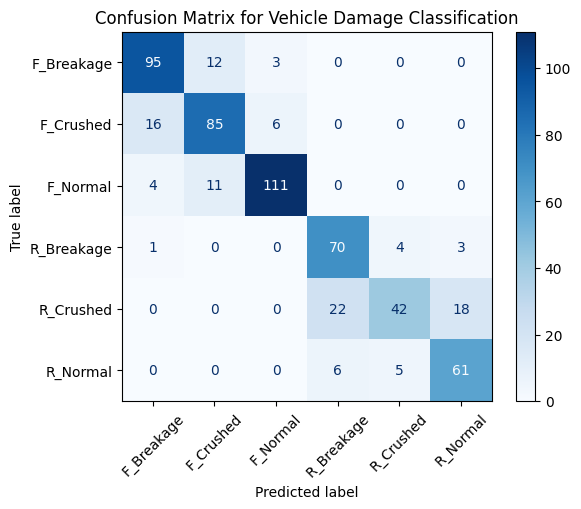

In [34]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

conf_matrix = confusion_matrix(labels, predictions, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix for Vehicle Damage Classification")
plt.show()

Our dataset is in a way that the model can get confused by slightly dented car to be a normal car. That is why maybe the confusion matrix has many falsely classified results. If we want to improve the model further we can acquire moe images(a bigger dataset) and the model is likely to learn better.

ther approach is we can convert the mages to grayscale.then we can use ensemble approach. since we ae losing colours we might lose some features related to that colour.

We can choose different approaches. project can be extended to phase2 by acquiring more data, more data augmentation techniques, using different pre trained models. we can also try latest approach like LLMs

### Save the Model

In [35]:
torch.save(model.state_dict(), '../Model/saved_model.pth')